In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
import sys
import argparse
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns


In [6]:
df_CoA = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/chart_of_account_OB.csv')
df_customer = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/customer_table.csv')
df_employee = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/employee_table.csv')
df_Master_txn = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/Master_txn_table.csv')
df_payment_method = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/payment_method.csv')
df_product_service = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/product_service_table.csv')
df_vendor = pd.read_csv('/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/vendor_table.csv')

In [14]:
dfs = {
    "CoA": df_CoA,
    "Customer": df_customer,
    "Employee": df_employee,
    "Master_txn": df_Master_txn,
    "Payment_Method": df_payment_method,
    "Product_Service": df_product_service,
    "Vendor": df_vendor
}

for name, df in dfs.items():
    print(f"\n{name} TABLE")
    print("-"*40)
    print("Shape:", df.shape)
    print("\nColumns:\n", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nData Types:\n", df.dtypes)


CoA TABLE
----------------------------------------
Shape: (2430, 5)

Columns:
 ['Unnamed: 0', 'Business Id', 'Account name', 'Account Full Name', 'Account type']

Missing Values:
 Unnamed: 0           0
Business Id          0
Account name         0
Account Full Name    0
Account type         0
dtype: int64

Data Types:
 Unnamed: 0            int64
Business Id           int64
Account name         object
Account Full Name    object
Account type         object
dtype: object

Customer TABLE
----------------------------------------
Shape: (50000, 13)

Columns:
 ['Unnamed: 0', 'Business Id', 'Customer name', 'Customer full name', 'Billing address', 'Billing city', 'Billing state', 'Billing ZIP code', 'Shipping address', 'Shipping city', 'Shipping state', 'Shipping ZIP code', 'Balance']

Missing Values:
 Unnamed: 0            0
Business Id           0
Customer name         0
Customer full name    0
Billing address       0
Billing city          0
Billing state         0
Billing ZIP code      

In [15]:
import re

def normalize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
    )
    return df

In [16]:
for name in dfs:
    dfs[name] = normalize_columns(dfs[name])

In [17]:
for name, df in dfs.items():
    print(f"\n{name} Normalized Columns:")
    print(df.columns.tolist())


CoA Normalized Columns:
['unnamed_0', 'business_id', 'account_name', 'account_full_name', 'account_type']

Customer Normalized Columns:
['unnamed_0', 'business_id', 'customer_name', 'customer_full_name', 'billing_address', 'billing_city', 'billing_state', 'billing_zip_code', 'shipping_address', 'shipping_city', 'shipping_state', 'shipping_zip_code', 'balance']

Employee Normalized Columns:
['unnamed_0', 'business_id', 'employee_name', 'employee_id', 'hire_date', 'billing_rate', 'deleted']

Master_txn Normalized Columns:
['unnamed_03', 'unnamed_02', 'unnamed_01', 'unnamed_0', 'business_id', 'transaction_id', 'transaction_date', 'transaction_type', 'amount', 'created_date', 'created_user', 'account', 'ar_paid', 'ap_paid', 'due_date', 'open_balance', 'po_status', 'estimate_status', 'customer_name', 'vendor_name', 'product_service', 'quantity', 'rate', 'credit', 'debit', 'sale', 'purchase', 'billable', 'invoiced', 'cleared', 'payment_method', 'misc_business_specific_fields']

Payment_Meth

In [18]:
print(df_Master_txn)

        unnamed_03  unnamed_02  unnamed_01  unnamed_0  business_id  \
0                0           0           0      24925            2   
1                1           1           1      24926            2   
2                2           2           2      24927            2   
3                3           3           3      24928            2   
4                4           4           4      24929            2   
...            ...         ...         ...        ...          ...   
810054      810054      810054      810054     800220           28   
810055      810055      810055      810055     800221           28   
810056      810056      810056      810056     800222           28   
810057      810057      810057      810057     800223           28   
810058      810058      810058      810058     800224           28   

        transaction_id transaction_date    transaction_type    amount  \
0                 6422       2010-12-27  Credit Card Credit  34985.71   
1            

In [12]:
if 'date' in df_Master_txn.columns:
    df_Master_txn['date'] = pd.to_datetime(df_Master_txn['date'], errors='coerce')

print(df_Master_txn)

        unnamed_03  unnamed_02  unnamed_01  unnamed_0  business_id  \
0                0           0           0      24925            2   
1                1           1           1      24926            2   
2                2           2           2      24927            2   
3                3           3           3      24928            2   
4                4           4           4      24929            2   
...            ...         ...         ...        ...          ...   
810054      810054      810054      810054     800220           28   
810055      810055      810055      810055     800221           28   
810056      810056      810056      810056     800222           28   
810057      810057      810057      810057     800223           28   
810058      810058      810058      810058     800224           28   

        transaction_id transaction_date    transaction_type    amount  \
0                 6422       2010-12-27  Credit Card Credit  34985.71   
1            

# For CoA

In [ ]:
print("Shape:", df_.shape)
print("\nColumns:", df_CoA.columns.tolist())
print("\nMissing Values:\n", df_CoA.isnull().sum())
print("\nData Types:\n", df_CoA.dtypes)

Shape: (2430, 5)

Columns: ['Unnamed: 0', 'Business Id', 'Account name', 'Account Full Name', 'Account type']

Missing Values:
 Unnamed: 0           0
Business Id          0
Account name         0
Account Full Name    0
Account type         0
dtype: int64

Data Types:
 Unnamed: 0            int64
Business Id           int64
Account name         object
Account Full Name    object
Account type         object
dtype: object


In [6]:
df_CoA.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,2430.0,NaN,NaN,NaN,1214.5,701.6249,0.0,607.25,1214.5,1821.75,2429.0
Business Id,2430.0,NaN,NaN,NaN,15.0,7.790484,2.0,8.0,15.0,22.0,28.0
Account name,2430,340,Equipment Rental,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Full Name,2430,340,Equipment Rental,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account type,2430,13,Expenses,1134,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
plt.figure()
df_CoA['account_type'].value_counts().plot(kind='bar')
plt.title("Distribution of Account Types")
plt.show()

KeyError: 'account_type'

<Figure size 640x480 with 0 Axes>

In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = "/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables"  
FILES = [
    "Master_txn_table.csv",
    "chart_of_account_OB.csv",
    "customer_table.csv",
    "vendor_table.csv",
    "employee_table.csv",
    "product_service_table.csv",
    "payment_method.csv"
]

def load_data():
    dfs = {}
    for f in FILES:
        path = os.path.join(DATA_DIR, f)
        if os.path.exists(path):
            name = f.replace(".csv", "")
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
            dfs[name] = df
    return dfs

dfs = load_data()

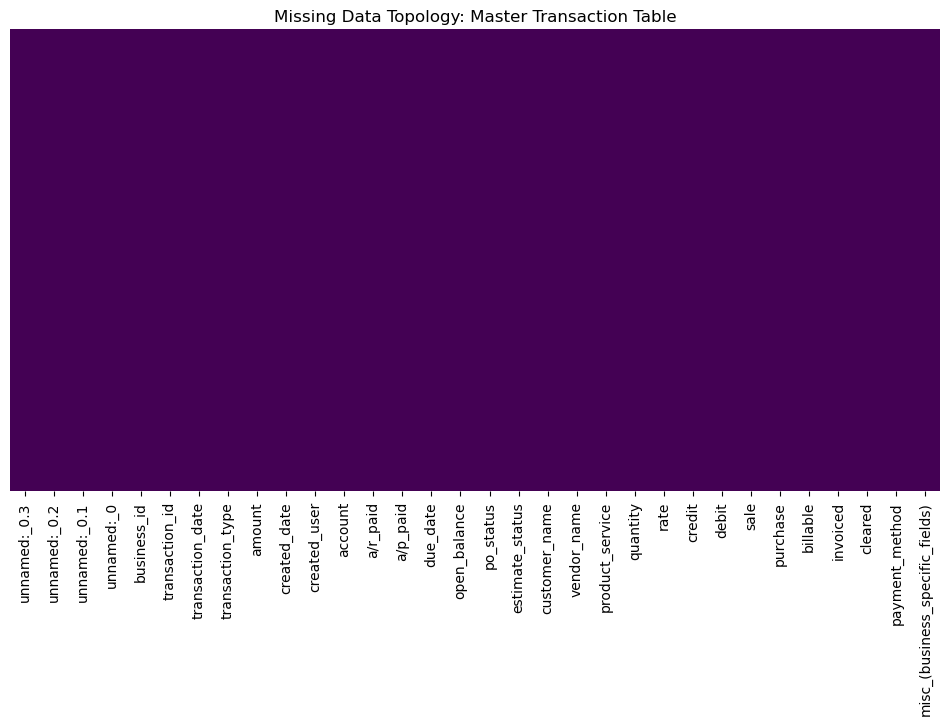

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(dfs['Master_txn_table'].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Topology: Master Transaction Table")
plt.show()





In [12]:
print("--- CARDINALITY AUDIT ---")
for name, df in dfs.items():
    print(f"\nTABLE: {name} ({len(df)} rows)")
    print(df.nunique().to_string())

--- CARDINALITY AUDIT ---

TABLE: Master_txn_table (810059 rows)
unnamed:_0.3                       810059
unnamed:_0.2                       810059
unnamed:_0.1                       810059
unnamed:_0                         810059
business_id                            27
transaction_id                     169525
transaction_date                    10958
transaction_type                       21
amount                                107
created_date                        11268
created_user                           27
account                               323
a/r_paid                                2
a/p_paid                                2
due_date                            11440
open_balance                       165360
po_status                               1
estimate_status                         1
customer_name                       70980
vendor_name                          1088
product_service                       267
quantity                               72
rate       

In [14]:
# Child/Dimension tables
txn = dfs['Master_txn_table']

cust = dfs['customer_table']
vend = dfs['vendor_table']
coa = dfs['chart_of_account_OB']

merged_cust = txn.merge(cust, on=['business_id', 'customer_name'], how='left', indicator=True)
cust_coverage = (merged_cust['_merge'] == 'both').mean() * 100

merged_vend = txn.merge(vend, on=['business_id', 'vendor_name'], how='left', indicator=True)
vend_coverage = (merged_vend['_merge'] == 'both').mean() * 100

merged_coa = txn.merge(coa, left_on=['business_id', 'account'], right_on=['business_id', 'account_name'], how='left', indicator=True)
coa_coverage = (merged_coa['_merge'] == 'both').mean() * 100

print("--- RELATIONAL INTEGRITY SCORES ---")
print(f"Chart of Accounts Coverage: {coa_coverage:.2f}%")
print(f"Customer Coverage: {cust_coverage:.2f}%")
print(f"Vendor Coverage: {vend_coverage:.2f}%")

--- RELATIONAL INTEGRITY SCORES ---
Chart of Accounts Coverage: 100.00%
Customer Coverage: 0.27%
Vendor Coverage: 0.00%


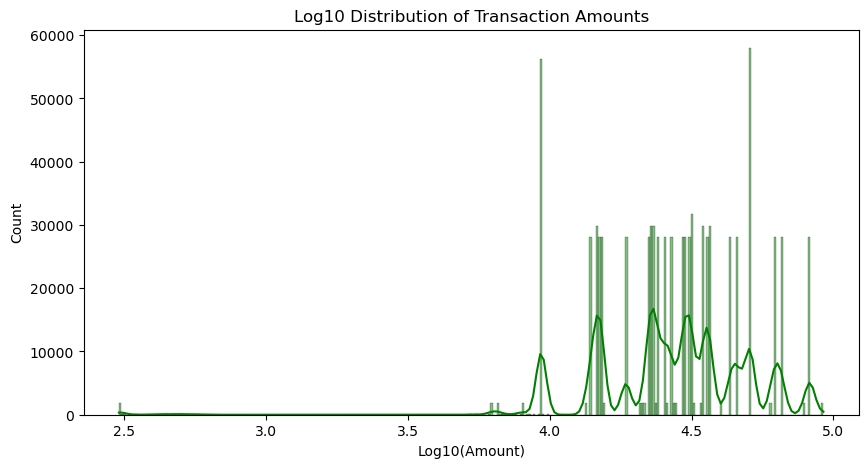

In [15]:
import numpy as np

valid_amts = txn[txn['amount'] > 0]['amount']

plt.figure(figsize=(10, 5))
sns.histplot(np.log10(valid_amts), kde=True, color='green')
plt.title("Log10 Distribution of Transaction Amounts")
plt.xlabel("Log10(Amount)")
plt.show()

/tmp/ipykernel_5774/659834274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


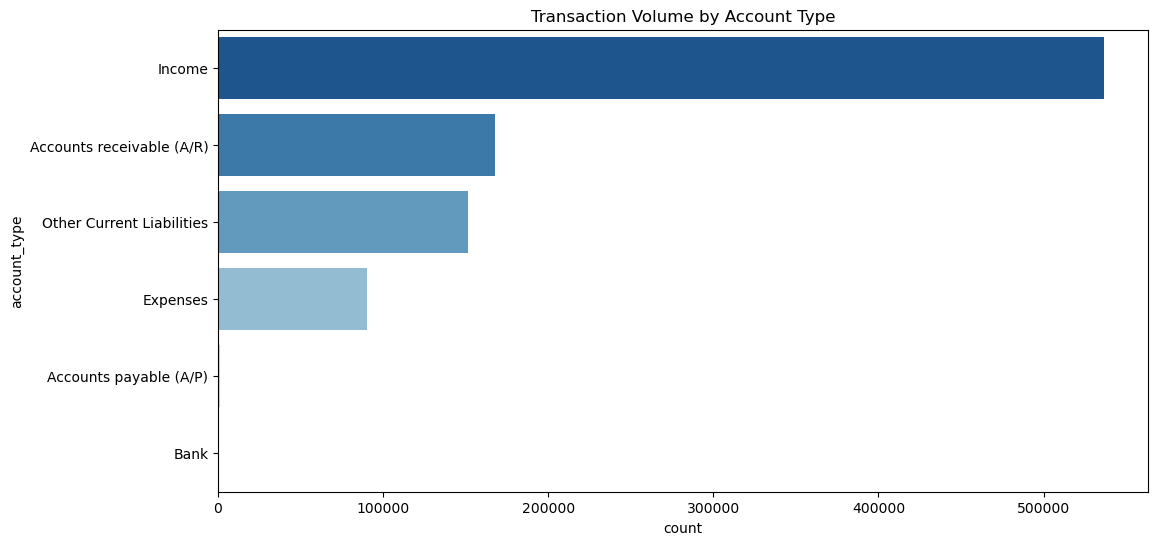

In [16]:
rich_txn = txn.merge(coa, left_on=['business_id', 'account'], right_on=['business_id', 'account_name'])

plt.figure(figsize=(12, 6))
sns.countplot(
    y='account_type',
    data=rich_txn,
    order=rich_txn['account_type'].value_counts().index,
    palette='Blues_r'
)
plt.title("Transaction Volume by Account Type")
plt.show()

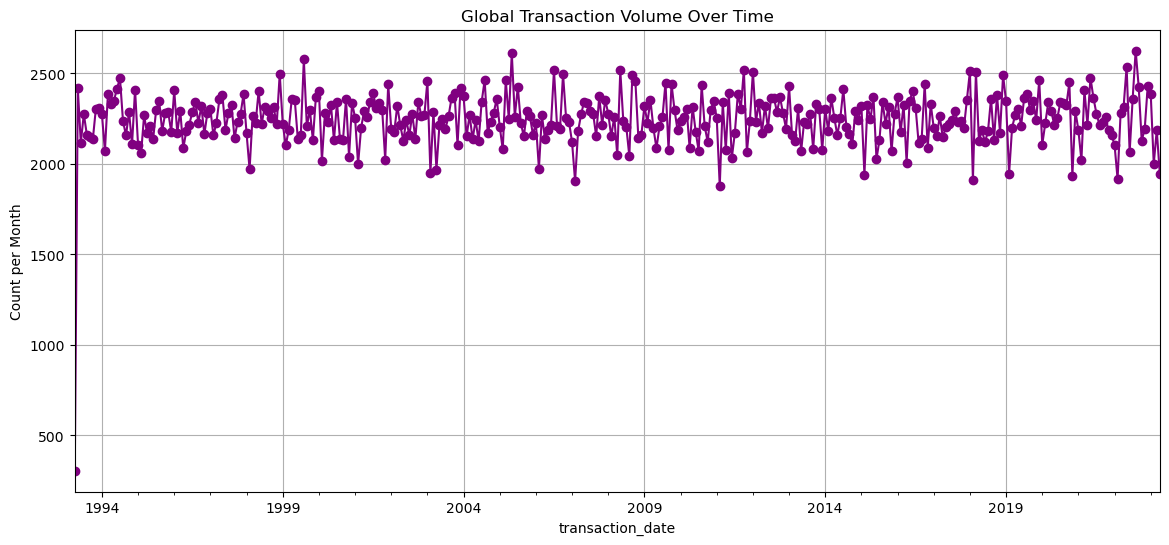

In [17]:
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'], errors='coerce')
monthly_vol = txn.groupby(txn['transaction_date'].dt.to_period('M')).size()

plt.figure(figsize=(14, 6))
monthly_vol.plot(kind='line', marker='o', color='purple')
plt.title("Global Transaction Volume Over Time")
plt.ylabel("Count per Month")
plt.grid(True)
plt.show()

In [18]:
def classify(row):
    acc = str(row['account']).lower()
    prod = str(row['product_service']).lower()
    if 'job materials' in acc or 'job materials' in prod:
        return 'Construction'
    if 'inventory' in acc or 'shipping' in prod:
        return 'Retail'
    if 'consulting' in acc or 'service' in prod:
        return 'Service'
    return 'Other'

sample_txn = txn.sample(50000).copy()
sample_txn['Industry_Context'] = sample_txn.apply(classify, axis=1)

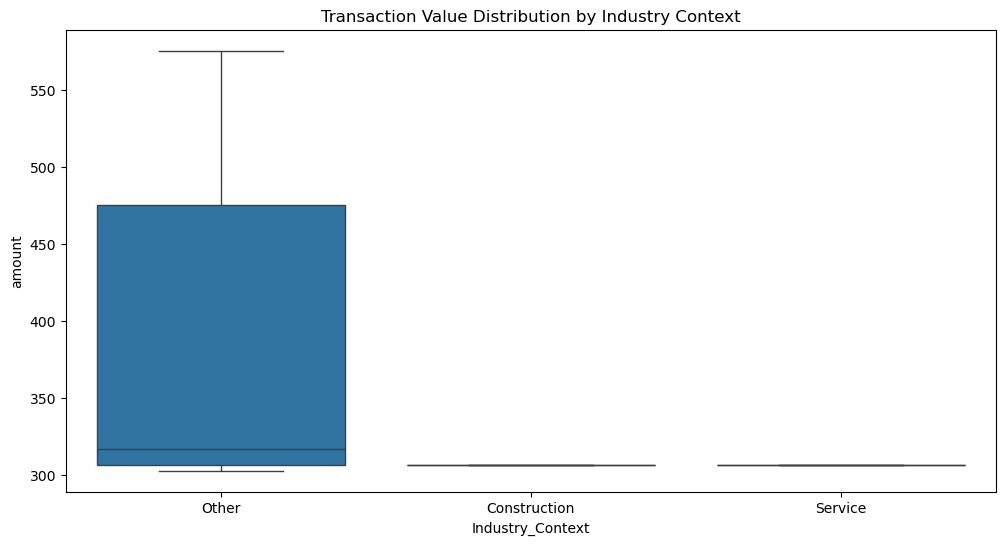

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Industry_Context',
    y='amount',
    data=sample_txn[sample_txn['amount'] < 5000]
)
plt.title("Transaction Value Distribution by Industry Context")
plt.show()

In [21]:
industry_df = pd.read_csv("/home/bisag/Documents/Devanshi_Intern/BookSQL/BookSQL_Generation/data/Industry_Details.csv")
industry_df.head()

,Industry,Business,Account Name,Account Type,Product_Service,Product_Service_Type
0,Accommodation and Food Services,Accommodation and Food Services Industry,Hotels and motel services,Income,Casino Hotels,Service
1,Accommodation and Food Services,Accommodation and Food Services Industry,Campground and RV park services,Income,Camping and Parking,Service
2,Accommodation and Food Services,Accommodation and Food Services Industry,Other accommodation services,Income,Traveller accomodation,Service
3,Accommodation and Food Services,Accommodation and Food Services Industry,Full-service restaurants,Income,Drinking and Special Food,Service
4,Accommodation and Food Services,Accommodation and Food Services Industry,Fast food restaurants,Income,Fast food,Service


In [22]:
df_industry = pd.read_csv("/home/bisag/Documents/Devanshi_Intern/BookSQL/BookSQL_Generation/data/Industry_Details.csv")
df_industry.columns = df_industry.columns.str.strip().str.lower().str.replace(" ", "_")

df_industry.head()

,industry,business,account_name,account_type,product_service,product_service_type
0,Accommodation and Food Services,Accommodation and Food Services Industry,Hotels and motel services,Income,Casino Hotels,Service
1,Accommodation and Food Services,Accommodation and Food Services Industry,Campground and RV park services,Income,Camping and Parking,Service
2,Accommodation and Food Services,Accommodation and Food Services Industry,Other accommodation services,Income,Traveller accomodation,Service
3,Accommodation and Food Services,Accommodation and Food Services Industry,Full-service restaurants,Income,Drinking and Special Food,Service
4,Accommodation and Food Services,Accommodation and Food Services Industry,Fast food restaurants,Income,Fast food,Service


In [23]:
txn['account_name'] = txn['account'].str.lower().str.strip()
df_industry['account_name'] = df_industry['account_name'].str.lower().str.strip()

txn['product_service_cleaned'] = txn['product_service'].str.lower().str.strip()
df_industry['product_service'] = df_industry['product_service'].str.lower().str.strip()

In [24]:
txn_ind = txn.merge(
    df_industry,
    how='left',
    left_on=['account_name', 'product_service_cleaned'],
    right_on=['account_name', 'product_service']
)

In [25]:
txn_ind_alt = txn.merge(
    df_industry,
    how='left',
    on='account_name'
)

In [26]:
coverage = txn_ind['industry'].notnull().mean() * 100
print(f"Industry Label Coverage: {coverage:.2f}%")

Industry Label Coverage: 26.15%


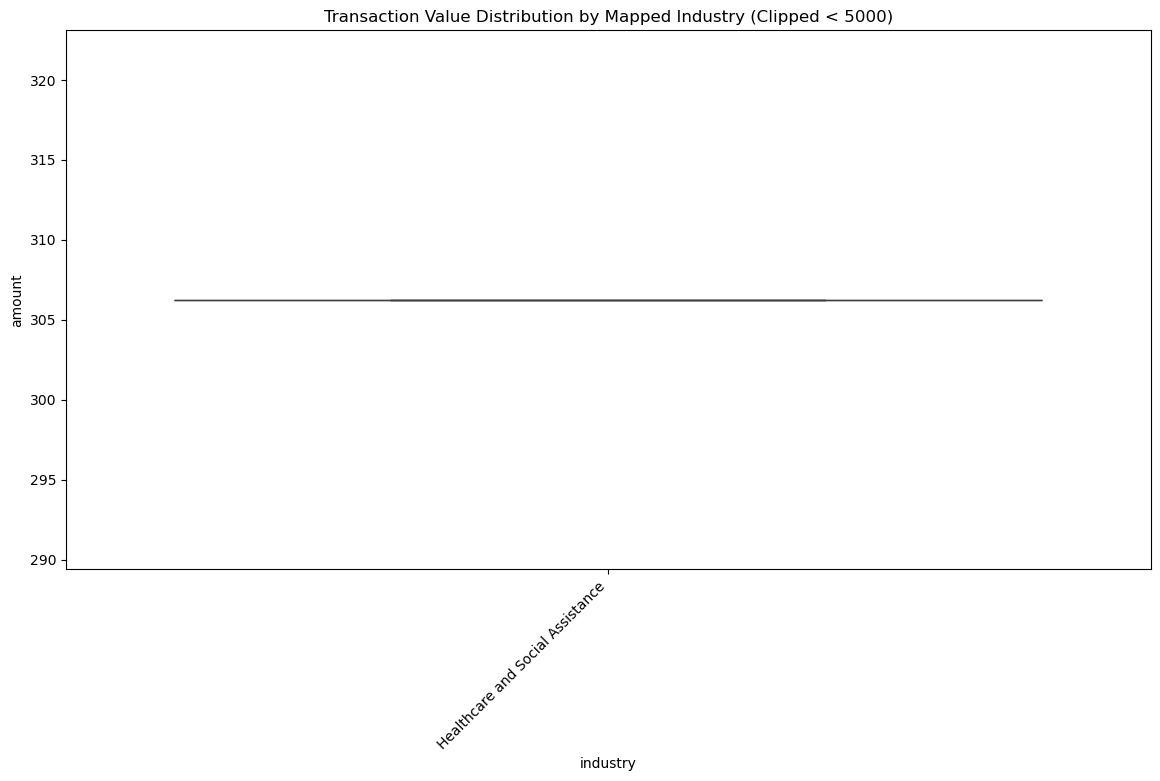

In [27]:
plt.figure(figsize=(14, 7))
sns.boxplot(
    x='industry',
    y='amount',
    data=txn_ind[txn_ind['amount'] < 5000]   # visualization limit
)
plt.title("Transaction Value Distribution by Mapped Industry (Clipped < 5000)")
plt.xticks(rotation=45, ha='right')
plt.show()

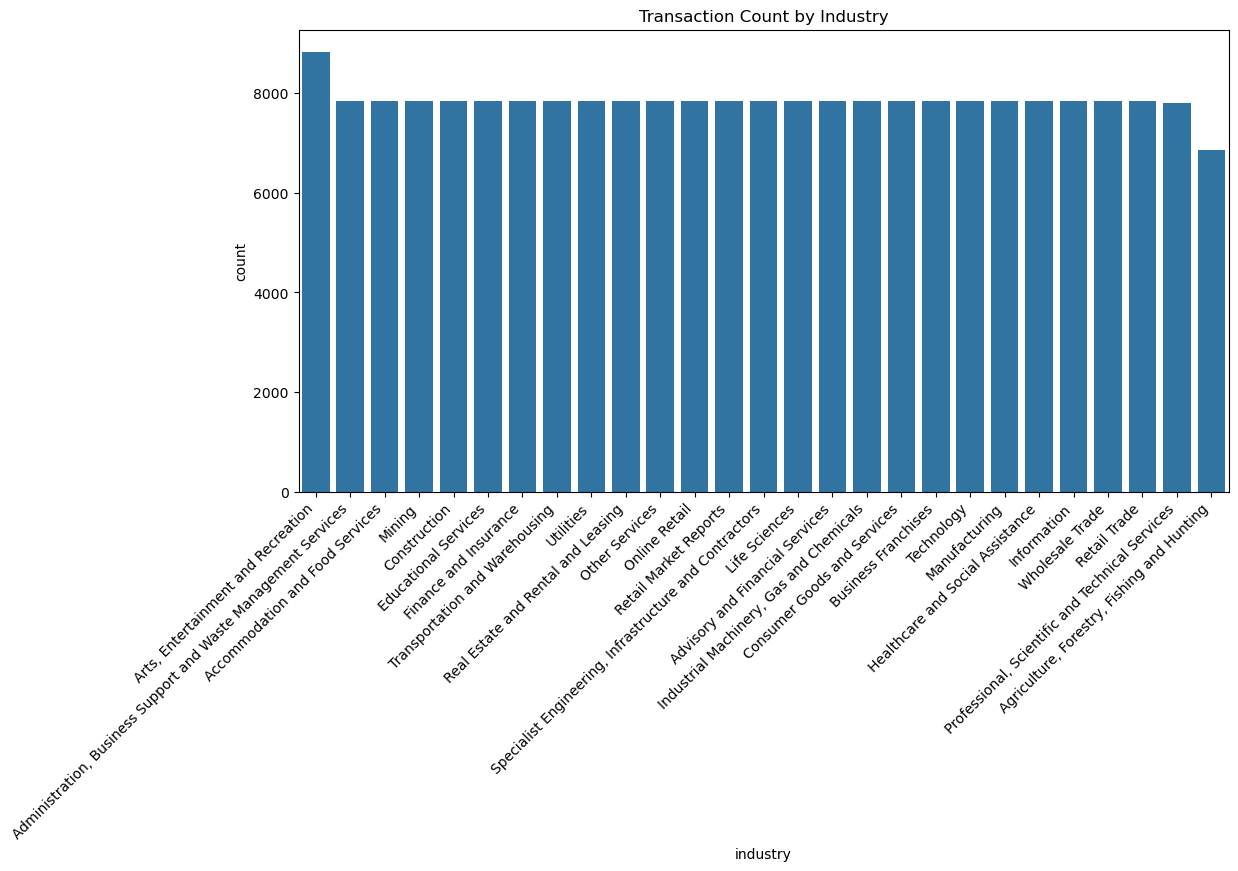

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x='industry',
    data=txn_ind,
    order=txn_ind['industry'].value_counts().index
)
plt.title("Transaction Count by Industry")
plt.xticks(rotation=45, ha='right')
plt.show()

In [29]:
industry_stats = txn_ind.groupby('industry')['amount'].agg(['median','mean','std','count'])
industry_stats.sort_values(by='median', ascending=False)

,median,mean,std,count
industry,,,,
Construction,82658.99,78613.031747,15003.980846,7847
Educational Services,65222.37,64221.478083,4018.848977,7847
Advisory and Financial Services,61850.84,63797.140208,7874.542039,7847
"Administration, Business Support and Waste Management Services",50859.18,49868.295018,3823.846484,7847
"Professional, Scientific and Technical Services",50617.44,48088.694360,9378.519324,7803
Manufacturing,46049.15,45021.650802,3931.284807,7846
Retail Trade,43599.00,41070.204138,9377.665271,7846
Healthcare and Social Assistance,36753.38,34288.947293,9140.124467,7846
Transportation and Warehousing,35875.48,35747.693502,1064.769456,7847


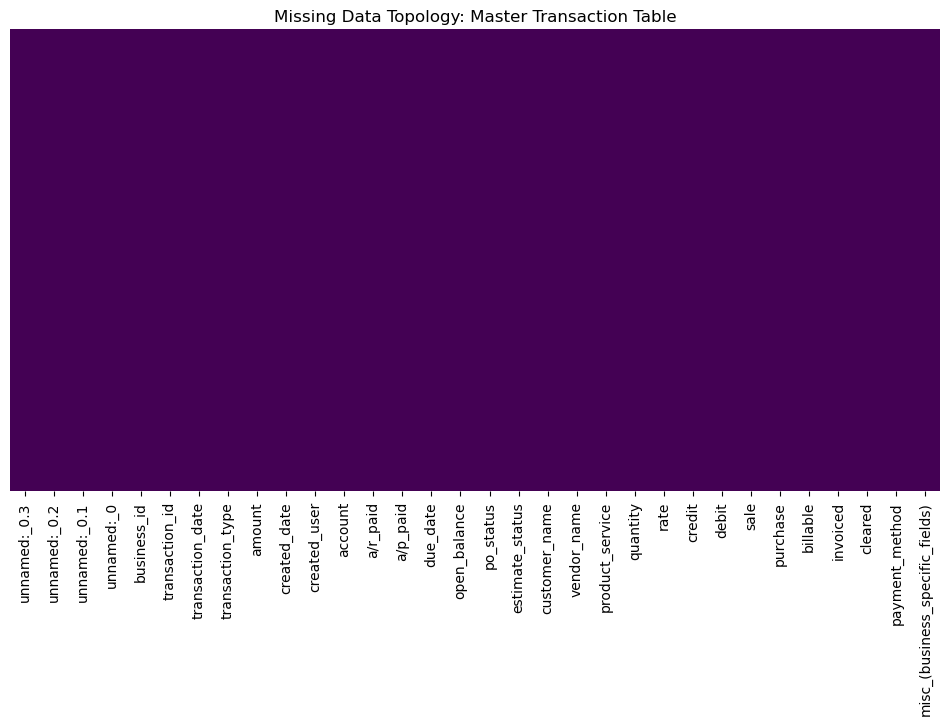

--- CARDINALITY AUDIT ---

TXN (810059 rows)
unnamed:_0.3                       810059
unnamed:_0.2                       810059
unnamed:_0.1                       810059
unnamed:_0                         810059
business_id                            27
transaction_id                     169525
transaction_date                    10958
transaction_type                       21
amount                                107
created_date                        11268
created_user                           27
account                               323
a/r_paid                                2
a/p_paid                                2
due_date                            11440
open_balance                       165360
po_status                               1
estimate_status                         1
customer_name                       70980
vendor_name                          1088
product_service                       267
quantity                               72
rate                           

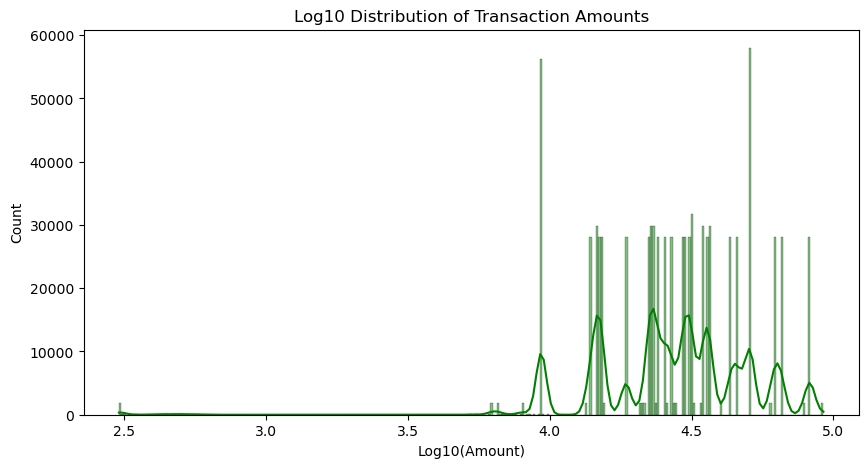

/tmp/ipykernel_5774/1420137985.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="account_type", data=rich_txn, order=rich_txn["account_type"].value_counts().index, palette="Blues_r")


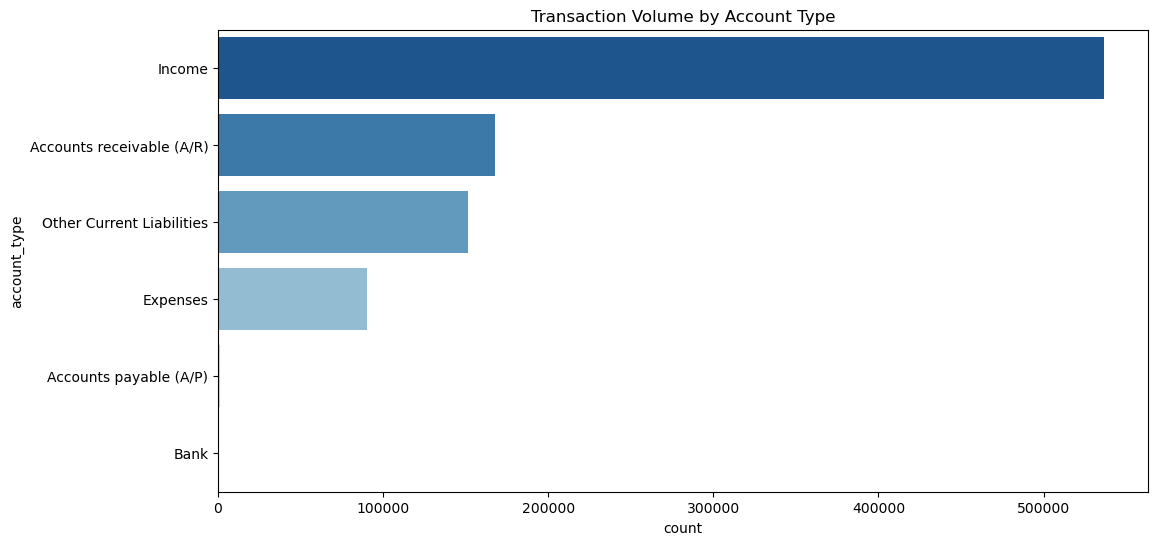

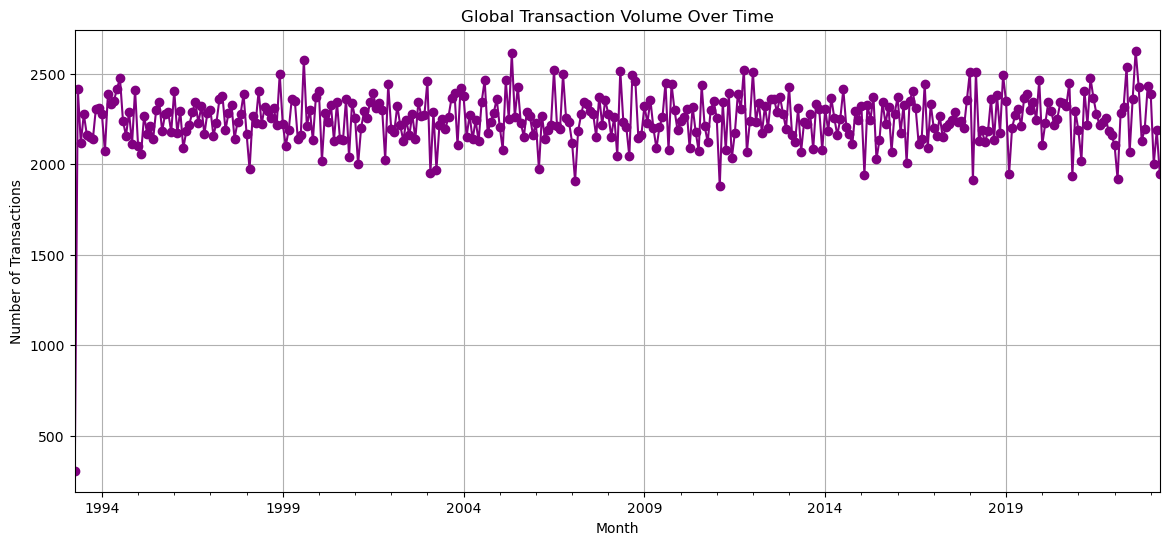


Industry Mapping Coverage: 26.15%


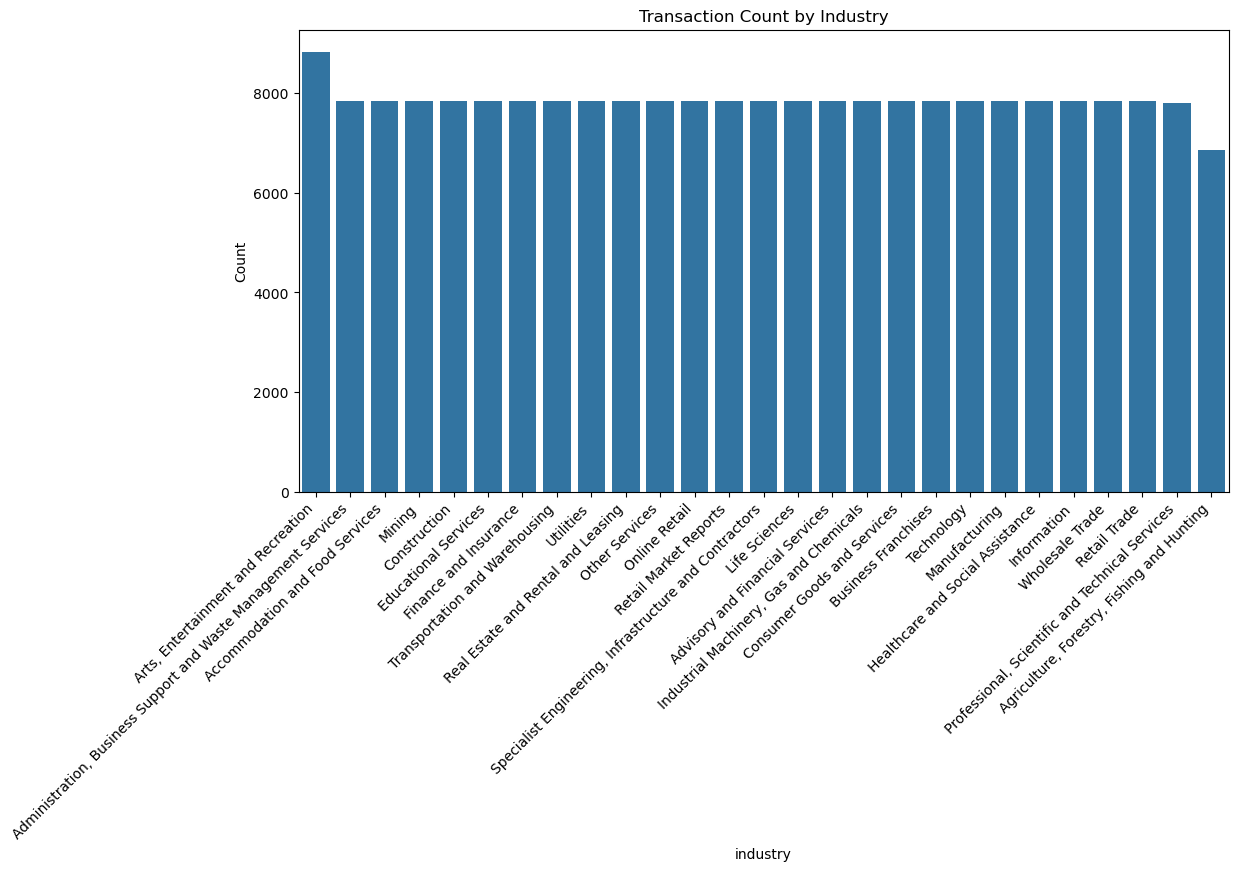

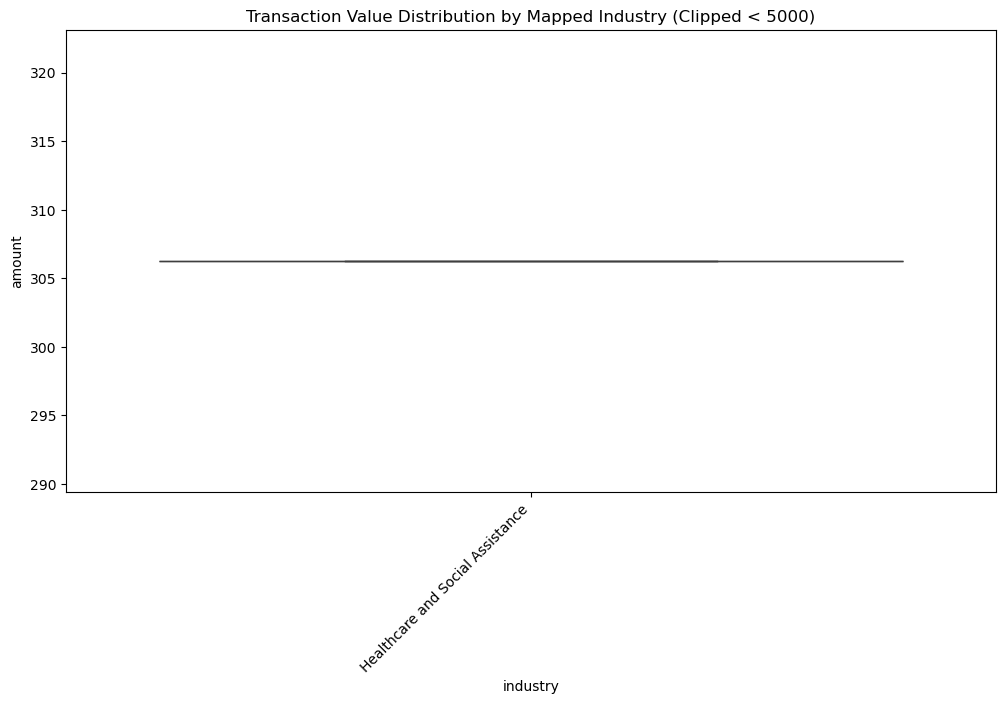

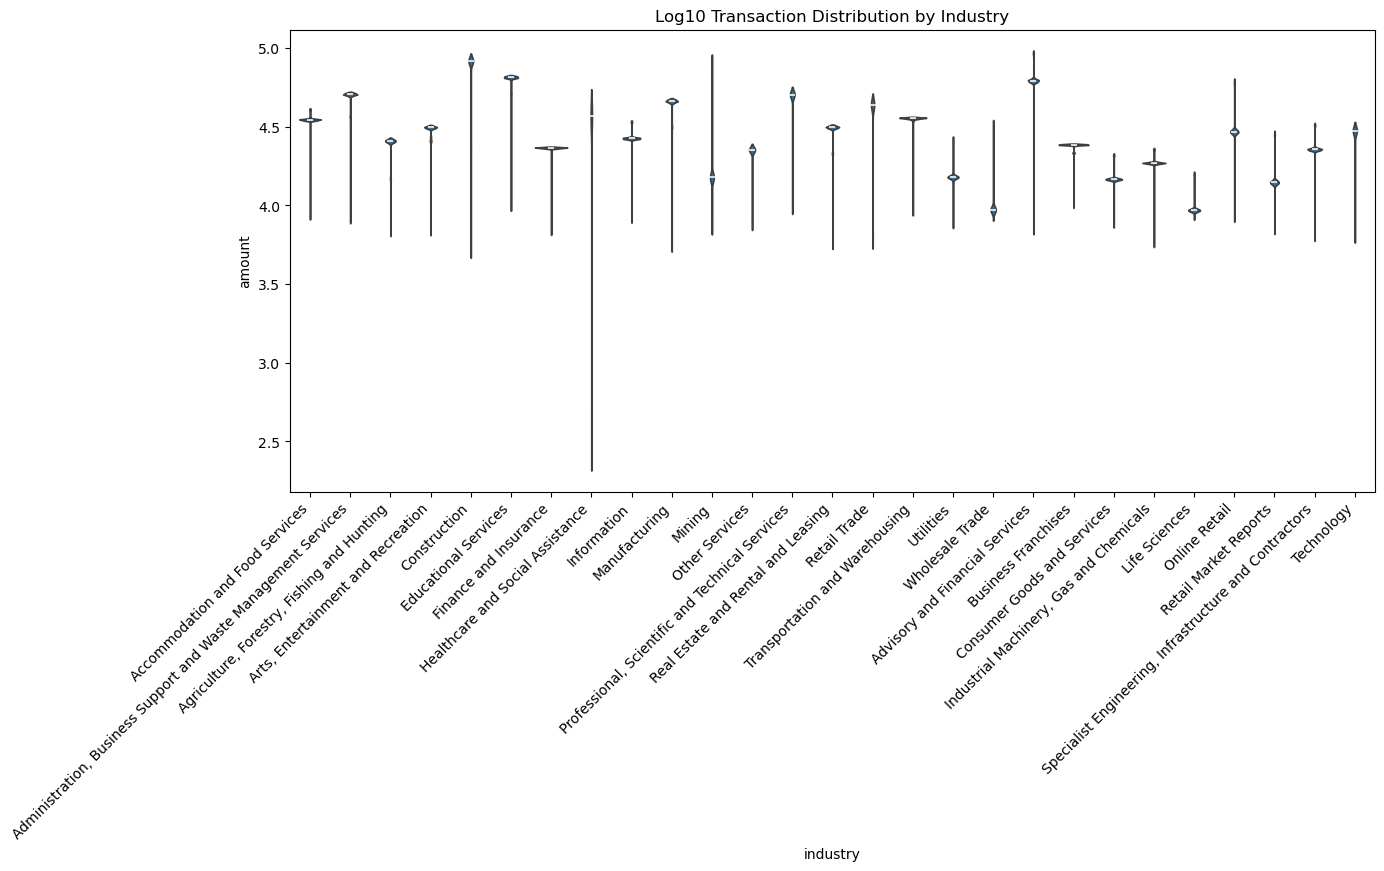


--- Industry Transaction Statistics ---
                                                                count          mean    median           std
industry                                                                                                   
Construction                                                     7847  78613.031747  82658.99  15003.980846
Educational Services                                             7847  64221.478083  65222.37   4018.848977
Advisory and Financial Services                                  7847  63797.140208  61850.84   7874.542039
Administration, Business Support and Waste Management Services   7847  49868.295018  50859.18   3823.846484
Professional, Scientific and Technical Services                  7803  48088.694360  50617.44   9378.519324
Manufacturing                                                    7846  45021.650802  46049.15   3931.284807
Retail Trade                                                     7846  41070.204138  43599.00  

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- 1. Load Data (Paths may vary) ----
DATA_DIR = "/home/bisag/Documents/Devanshi_Intern/BookSQL/DATA/BookSQL/Tables/"  # Update if needed

files = {
    "txn": "Master_txn_table.csv",
    "coa": "chart_of_account_OB.csv",
    "cust": "customer_table.csv",
    "vend": "vendor_table.csv",
    "emp": "employee_table.csv",
    "prod": "product_service_table.csv",
    "pm": "payment_method.csv",
    "industry": "Industry_Details.csv"
}

dfs = {}
for k, f in files.items():
    dfs[k] = pd.read_csv(DATA_DIR + f)
    # Normalize column names
    dfs[k].columns = dfs[k].columns.str.strip().str.lower().str.replace(" ", "_")

txn = dfs["txn"]
coa = dfs["coa"]
df_industry = dfs["industry"]

# ---- 2. Missing Value Heatmap (Master Transaction Table) ----
plt.figure(figsize=(12,6))
sns.heatmap(txn.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Topology: Master Transaction Table")
plt.show()

# ---- 3. Cardinality Audit ----
print("--- CARDINALITY AUDIT ---")
for name, df in dfs.items():
    print(f"\n{name.upper()} ({len(df)} rows)")
    print(df.nunique().to_string())

# ---- 4. Referential Integrity Coverage ----
merged_coa = txn.merge(coa, left_on=["business_id", "account"], right_on=["business_id", "account_name"], how='left', indicator=True)
coa_coverage = (merged_coa["_merge"] == "both").mean() * 100

merged_cust = txn.merge(dfs["cust"], on=["business_id", "customer_name"], how='left', indicator=True)
cust_coverage = (merged_cust["_merge"] == "both").mean() * 100

merged_vend = txn.merge(dfs["vend"], on=["business_id", "vendor_name"], how='left', indicator=True)
vend_coverage = (merged_vend["_merge"] == "both").mean() * 100

print("\n--- RELATIONAL INTEGRITY SCORES ---")
print(f"Chart of Accounts Coverage: {coa_coverage:.2f}%")
print(f"Customer Coverage: {cust_coverage:.2f}%")
print(f"Vendor Coverage: {vend_coverage:.2f}%")

# ---- 5. Financial Distributions ----
# Log Distribution of transaction amounts
valid_amts = txn[txn["amount"] > 0]["amount"]
plt.figure(figsize=(10,5))
sns.histplot(np.log10(valid_amts), kde=True, color="green")
plt.title("Log10 Distribution of Transaction Amounts")
plt.xlabel("Log10(Amount)")
plt.show()

# Transaction volume by account type
rich_txn = txn.merge(coa, left_on=["business_id", "account"], right_on=["business_id", "account_name"])
plt.figure(figsize=(12,6))
sns.countplot(y="account_type", data=rich_txn, order=rich_txn["account_type"].value_counts().index, palette="Blues_r")
plt.title("Transaction Volume by Account Type")
plt.show()

# ---- 6. Temporal Dynamics ----
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"], errors="coerce")
monthly_vol = txn.groupby(txn["transaction_date"].dt.to_period("M")).size()

plt.figure(figsize=(14,6))
monthly_vol.plot(kind="line", marker="o", color="purple")
plt.title("Global Transaction Volume Over Time")
plt.ylabel("Number of Transactions")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# ---- 7. Industry Mapping & Profiling ----
# Normalize names for matching
txn["account_name_clean"] = txn["account"].str.lower().str.strip()
txn["product_service_clean"] = txn["product_service"].astype(str).str.lower().str.strip()

df_industry["account_name"] = df_industry["account_name"].str.lower().str.strip()
df_industry["product_service"] = df_industry["product_service"].str.lower().str.strip()

txn_ind = txn.merge(df_industry, how="left",
                    left_on=["account_name_clean", "product_service_clean"],
                    right_on=["account_name", "product_service"])

# Coverage of industry mapping
industry_cov = txn_ind["industry"].notnull().mean() * 100
print(f"\nIndustry Mapping Coverage: {industry_cov:.2f}%")

# Transaction count by industry
plt.figure(figsize=(12,6))
sns.countplot(x="industry", data=txn_ind,
              order=txn_ind["industry"].value_counts().index)
plt.title("Transaction Count by Industry")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.show()

# Transaction value boxes by industry (clipped)
plt.figure(figsize=(12,6))
sns.boxplot(x="industry", y="amount", data=txn_ind[txn_ind["amount"] < 5000])
plt.title("Transaction Value Distribution by Mapped Industry (Clipped < 5000)")
plt.xticks(rotation=45, ha="right")
plt.show()

# ---- 8. Industry Log-Scaled Distribution (Optional but Recommended) ----
plt.figure(figsize=(14,6))
sns.violinplot(x="industry", y=np.log10(txn_ind["amount"]+1), data=txn_ind)
plt.title("Log10 Transaction Distribution by Industry")
plt.xticks(rotation=45, ha="right")
plt.show()

# ---- 9. Summary Statistics Table (Industry-Based) ----
industry_stats = txn_ind.groupby("industry")["amount"].agg(["count", "mean", "median", "std"])
print("\n--- Industry Transaction Statistics ---")
print(industry_stats.sort_values(by="median", ascending=False).to_string())